In [1]:
# 시각화 글씨 깨짐 방지를 위한 폰트 설치 (실행 후, 런타임 다시 시작 뒤 2번 셀 실행)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

'sudo'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.
'sudo'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.
'rm'은(는) 내부 또는 외부 명령, 실행할 수 있는 프로그램, 또는
배치 파일이 아닙니다.


In [2]:
# 시각화 폰트 불러오기
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [26]:
from matplotlib import font_manager, rc
# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"  # 사용하고 있는 OS에 맞는 한글 폰트 경로로 수정해주세요.
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [3]:
!pip install pmdarima


[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

In [62]:
# 데이터 로드
file_path = 'solar_power_by_weather.csv'
# 인코딩을 여러 가지로 시도
encodings = ['utf-8', 'euc-kr', 'latin1']

for encoding in encodings:
    try:
        df = pd.read_csv(file_path, encoding=encoding)
        print(f"File successfully read with {encoding} encoding.")
        break
    except UnicodeDecodeError:
        print(f"Failed to read file with {encoding} encoding.")

# 필요한 컬럼만 선택
df = df[['일시', '태양광전체', '일조(hr)', '일사(MJ/m2)']]

# 날짜 형식 변환
df['일시'] = pd.to_datetime(df['일시'])

# 데이터 정렬
df = df.sort_values(by='일시')

# 결측치 처리
df = df.fillna(0)

# 인덱스를 datetime으로 설정
df.set_index('일시', inplace=True)

# 독립변수와 종속변수 설정
X = df[['일조(hr)', '일사(MJ/m2)']]
y = df['태양광전체']

# 데이터 스케일링
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

Failed to read file with utf-8 encoding.
File successfully read with euc-kr encoding.


In [65]:
# 3차원 데이터를 2차원으로 변환
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_seq_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])

# 1차원 배열로 변환
y_train_seq_flat = y_train_seq.flatten()
y_test_seq_flat = y_test_seq.flatten()

# DataFrame으로 변환
X_train_seq_df = pd.DataFrame(X_train_seq_flat)
X_test_seq_df = pd.DataFrame(X_test_seq_flat)
y_train_seq_series = pd.Series(y_train_seq_flat)
y_test_seq_series = pd.Series(y_test_seq_flat)

# CSV 파일로 저장
X_train_seq_df.to_csv('X_train_seq.csv', index=False)
X_test_seq_df.to_csv('X_test_seq.csv', index=False)
y_train_seq_series.to_csv('y_train_seq.csv', index=False, header=True)
y_test_seq_series.to_csv('y_test_seq.csv', index=False, header=True)

# 저장된 CSV 파일을 엑셀 파일로 합치기
csv_files = {
    'X_train_seq': 'X_train_seq.csv',
    'X_test_seq': 'X_test_seq.csv',
    'y_train_seq': 'y_train_seq.csv',
    'y_test_seq': 'y_test_seq.csv',
}

excel_file = 'Datasets2.xlsx'

try:
    with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
        for sheet_name, csv_file in csv_files.items():
            df = pd.read_csv(csv_file)
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f'엑셀 파일 "{excel_file}"이 생성되었습니다.')

except FileNotFoundError:
    print(f'파일을 찾을 수 없습니다: {csv_file}')

except Exception as e:
    print(f'오류 발생: {e}')

엑셀 파일 "Datasets2.xlsx"이 생성되었습니다.


In [29]:
# 시계열 데이터를 LSTM/GRU 입력 형식에 맞게 변환
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 30

# 전체 데이터에 대해 시퀀스 생성
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

In [30]:
# 데이터 분할 (훈련, 검증, 테스트)
train_size = int(len(X_seq) * 0.7)
val_size = int(len(X_seq) * 0.15)
X_train_seq, y_train_seq = X_seq[:train_size], y_seq[:train_size]
X_val_seq, y_val_seq = X_seq[train_size:train_size+val_size], y_seq[train_size:train_size+val_size]
X_test_seq, y_test_seq = X_seq[train_size+val_size:], y_seq[train_size+val_size:]

# 비시퀀스 모델을 위한 데이터 분할
X_train, y_train = X_scaled[time_steps:train_size+time_steps], y_scaled[time_steps:train_size+time_steps]
X_val, y_val = X_scaled[train_size+time_steps:train_size+val_size+time_steps], y_scaled[train_size+time_steps:train_size+val_size+time_steps]
X_test, y_test = X_scaled[train_size+val_size+time_steps:], y_scaled[train_size+val_size+time_steps:]

# 시계열 교차검증 설정
tscv = TimeSeriesSplit(n_splits=5)

In [31]:
# LSTM/GRU 모델 생성 및 훈련 함수
def create_and_fit_model(model_type, X_train, y_train, X_val, y_val, units=50, optimizer='adam', epochs=100, batch_size=32):
    if model_type == 'LSTM':
        model = Sequential([
            LSTM(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
            Dense(1)
        ])
    elif model_type == 'GRU':
        model = Sequential([
            GRU(units, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
            Dense(1)
        ])

    model.compile(optimizer=optimizer, loss='mse')
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
    return model, history

In [32]:
# 그리드 서치를 위한 파라미터 설정
lstm_params = {
    'units': [30, 50, 70],
    'optimizer': ['adam', 'rmsprop']
}

gru_params = {
    'units': [30, 50, 70],
    'optimizer': ['adam', 'rmsprop']
}

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

In [33]:
# 모델 및 그리드 서치 설정
models = {
    'LSTM': (create_and_fit_model, lstm_params),
    'GRU': (create_and_fit_model, gru_params),
    'Random Forest': (RandomForestRegressor(random_state=42), rf_params),
    'XGBoost': (XGBRegressor(random_state=42), xgb_params)
}

# 결과 저장을 위한 딕셔너리
results = {}

In [34]:
# 설비 용량의 합 (S)
S = 2400.4

# NMAE 계산 함수
def calculate_nmae(y_true, y_pred, S):
    mask = y_true >= 0.1 * S
    nmae = (np.mean(np.abs(y_true[mask] - y_pred[mask]) / S)) * 100
    return nmae

# 성능 평가 함수
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    nmae = calculate_nmae(y_true, y_pred, S)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, nmae, r2

In [35]:
# 각 모델에 대해 그리드 서치 수행
for name, (model, params) in models.items():
    print(f"Performing grid search for {name}...")

    if name in ['LSTM', 'GRU']:
        best_score = float('inf')
        best_params = None
        for units in params['units']:
            for optimizer in params['optimizer']:
                model, history = create_and_fit_model(name, X_train_seq, y_train_seq, X_val_seq, y_val_seq,
                                                      units=units, optimizer=optimizer)
                score = model.evaluate(X_val_seq, y_val_seq)
                if score < best_score:
                    best_score = score
                    best_params = {'units': units, 'optimizer': optimizer}
                    best_model = model
        results[name] = {'Best Model': best_model, 'Best Parameters': best_params, 'History': history}
    else:
        grid_search = GridSearchCV(estimator=model, param_grid=params, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train.ravel())
        results[name] = {'Best Model': grid_search.best_estimator_, 'Best Parameters': grid_search.best_params_}

    # 최적의 모델로 예측 수행
    if name in ['LSTM', 'GRU']:
        y_pred = results[name]['Best Model'].predict(X_test_seq)
        y_true = y_test_seq
    else:
        y_pred = results[name]['Best Model'].predict(X_test)
        y_true = y_test

    # 예측값 역스케일링
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1))
    y_true = scaler_y.inverse_transform(y_true.reshape(-1, 1))

    # 성능 평가
    mse, mae, nmae, r2 = calculate_metrics(y_true, y_pred)
    accuracy = r2 * 100

    results[name].update({
        'MSE': mse,
        'MAE': mae,
        'NMAE': nmae,
        'R2': r2,
        'Accuracy': accuracy
    })

Performing grid search for LSTM...


c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0618 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0713 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0625 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0617 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0633 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0544 
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002AD4A98B5E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retra

c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0630 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0541 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0698 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0572 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0612 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0591 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Performing grid search for Random Forest...
Performing grid search for XGBoost...


In [36]:
# ARIMA 모델링 프로세스
print("Performing ARIMA modeling...")

# ADF 테스트 함수
def adf_test(series, signif=0.05):
    result = adfuller(series, autolag='AIC')
    output = {
        'test_statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'n_lags': round(result[2], 4),
        'n_obs': result[3]
    }
    for key, value in result[4].items():
        output[f'critical_value ({key})'] = value
    if result[1] <= signif:
        output['stationary'] = True
    else:
        output['stationary'] = False
    return output

Performing ARIMA modeling...


In [45]:
# 훈련 데이터 준비
train_data = y[:train_size]

# ADF 테스트 수행
adf_result = adf_test(train_data)
print("ADF Test Result:")
print(adf_result)

ADF Test Result:
{'test_statistic': -3.6077, 'p-value': 0.0056, 'n_lags': 9, 'n_obs': 479, 'critical_value (1%)': -3.44407586647939, 'critical_value (5%)': -2.867592847097137, 'critical_value (10%)': -2.5699939338217668, 'stationary': True}


In [46]:
# 차분 수준 설정
kpss_diffs = pm.arima.ndiffs(train_data, alpha=0.05, test='kpss', max_d=5)
adf_diffs = pm.arima.ndiffs(train_data, alpha=0.05, test='adf', max_d=5)
n_diffs = max(kpss_diffs, adf_diffs)

print(f"Optimal number of differences: {n_diffs}")

Optimal number of differences: 1


In [47]:
# Auto-ARIMA 모델 학습
arima_model = pm.auto_arima(train_data, d=n_diffs, seasonal=True, suppress_warnings=True,
                            stepwise=True, n_jobs=-1, start_p=1, start_q=1, max_p=5, max_q=5)

print(arima_model.summary())

c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  489
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -4509.228
Date:                Wed, 03 Jul 2024   AIC                           9024.457
Time:                        23:49:12   BIC                           9037.028
Sample:                    01-01-2022   HQIC                          9029.395
                         - 05-04-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3783      0.036     10.440      0.000       0.307       0.449
ma.L1         -0.9361      0.013    -69.423      0.000      -0.963      -0.910
sigma2      6.202e+06   3.35e+05     18.525      0.0

c:\users\pya66\appdata\local\programs\python\python39\lib\site-packages\IPython\core\pylabtools.py:137: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


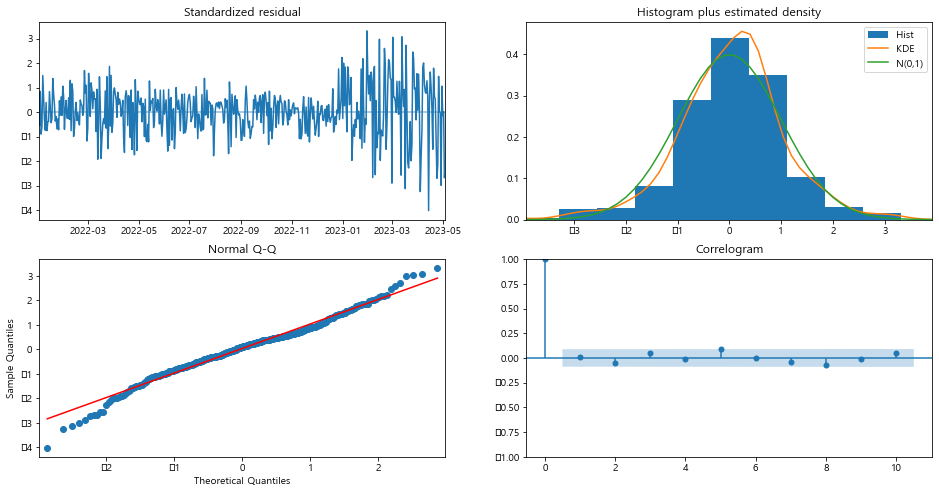

In [48]:
# ARIMA 모델 진단
arima_model.plot_diagnostics(figsize=(16,8))
plt.show()

In [49]:
# 예측 함수 정의
def forecast_one_step(model, new_observation):
    fc, conf_int = model.predict(n_periods=1, return_conf_int=True)
    return fc[0], conf_int[0]

# ARIMA 예측 수행
y_pred_arima = []
pred_upper = []
pred_lower = []

test_data = y[train_size+val_size:]

for new_ob in test_data:
    fc, conf = forecast_one_step(arima_model, new_ob)
    y_pred_arima.append(fc)
    pred_upper.append(conf[1])
    pred_lower.append(conf[0])
    arima_model.update(new_ob)

In [50]:
# 예측값을 Pandas Series로 변환하기 전에 y_pred_arima의 길이와 내용을 출력
print("Length of y_pred_arima:", len(y_pred_arima))
print("Contents of y_pred_arima:", y_pred_arima)

# test_data의 길이와 내용을 출력
print("Length of test_data:", len(test_data))
print("Contents of test_data:", test_data)

# test_data.index의 길이와 내용을 출력
print("Length of test_data.index:", len(test_data.index))
print("Contents of test_data.index:", test_data.index)

Length of y_pred_arima: 136
Contents of y_pred_arima: [4643.968606855761, 7833.72000094406, 6914.219905349966, 9170.079030429868, 8562.200273424607, 7680.202339019049, 5712.8825634395025, 6151.137432735284, 8451.391070810254, 9522.72551756987, 8846.389348063358, 7920.404139494058, 7236.24971178288, 5140.16202030337, 7391.188952369949, 5555.09218071599, 8105.399378402271, 8006.029610905393, 8116.466715174216, 8555.409975666647, 9628.510820929067, 9196.578420698861, 9475.150565624792, 9531.004953565614, 8116.852863198997, 9086.528362621353, 7471.303390655641, 7954.568629868875, 5433.009743617169, 8074.081717221727, 6461.023678922516, 6145.113458417303, 6216.77796579391, 7270.070667618714, 5431.528888649882, 7058.175894352409, 5434.098481473569, 6638.231154517141, 6021.184601634249, 6243.735139562467, 6422.002279711318, 8520.033105766897, 6861.357827269809, 8400.27154734369, 5404.617450042981, 7498.679792271121, 8968.0578890748, 5173.799373946382, 8082.841266626907, 7045.759396885709, 678

In [51]:
# 예측값을 Pandas Series로 변환 (타입 변환 추가)
y_pred_arima_df = pd.Series(y_pred_arima, index=test_data.index).astype(float)

# ARIMA 결과를 results 딕셔너리에 추가
results['ARIMA'] = {
    'Best Model': arima_model,
    'Best Parameters': arima_model.get_params(),
}

# ARIMA 성능 평가
arima_mse, arima_mae, arima_nmae, arima_r2 = calculate_metrics(test_data, y_pred_arima_df)
arima_accuracy = arima_r2 * 100

results['ARIMA'].update({
    'MSE': arima_mse,
    'MAE': arima_mae,
    'NMAE': arima_nmae,
    'R2': arima_r2,
    'Accuracy': arima_accuracy
})

print("ARIMA 성능 평가 완료")

ARIMA 성능 평가 완료


In [52]:
# 결과 출력
for name, metrics in results.items():
    print(f"\n{name} Results:")
    print(f"Best Parameters: {metrics['Best Parameters']}")
    print(f"MSE: {metrics['MSE']:.4f}")
    print(f"MAE: {metrics['MAE']:.4f}")
    print(f"NMAE: {metrics['NMAE']:.4f}")
    print(f"R2: {metrics['R2']:.4f}")
    print(f"Accuracy: {metrics['Accuracy']:.2f}%")

# 성능 비교 시각화
metrics = ['MSE', 'MAE', 'NMAE', 'R2']
model_names = list(results.keys())


LSTM Results:
Best Parameters: {'units': 70, 'optimizer': 'rmsprop'}
MSE: 7236496.6456
MAE: 2220.9253
NMAE: 92.5231
R2: 0.1900
Accuracy: 19.00%

GRU Results:
Best Parameters: {'units': 30, 'optimizer': 'rmsprop'}
MSE: 6808530.5048
MAE: 2160.5662
NMAE: 90.0086
R2: 0.2379
Accuracy: 23.79%

Random Forest Results:
Best Parameters: {'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 300}
MSE: 4123369.6040
MAE: 1607.1747
NMAE: 66.9545
R2: 0.5385
Accuracy: 53.85%

XGBoost Results:
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
MSE: 4622549.8896
MAE: 1710.8786
NMAE: 71.2747
R2: 0.4826
Accuracy: 48.26%

ARIMA Results:
Best Parameters: {'maxiter': 50, 'method': 'lbfgs', 'order': (1, 1, 1), 'out_of_sample_size': 0, 'scoring': 'mse', 'scoring_args': {}, 'seasonal_order': (0, 0, 0, 0), 'start_params': None, 'suppress_warnings': True, 'trend': None, 'with_intercept': False}
MSE: 7157376.9175
MAE: 2175.9589
NMAE: 90.6498
R2: 0.2607
Accuracy: 26.07%


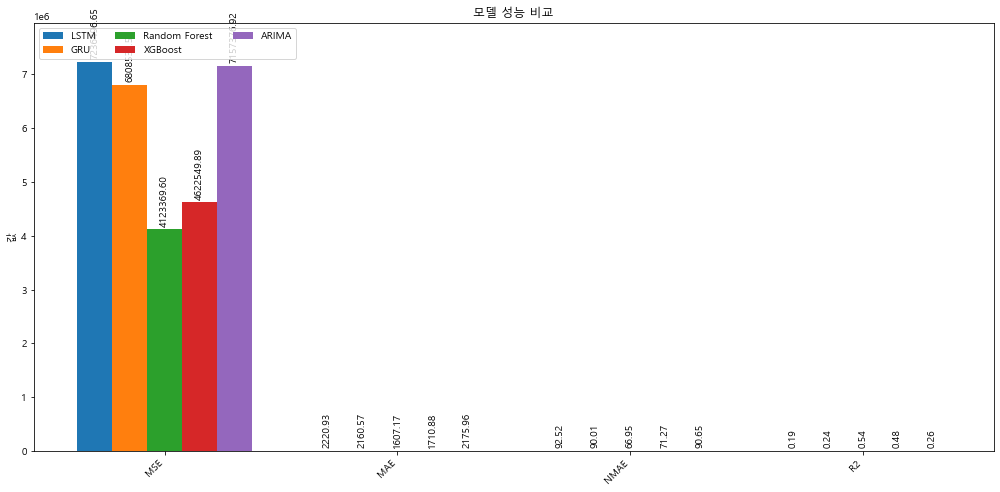

In [53]:
# 각 모델의 메트릭 값 추출
model_metrics = {name: [results[name][metric] for metric in metrics] for name in model_names}

x = np.arange(len(metrics))
width = 0.15
multiplier = 0

fig, ax = plt.subplots(figsize=(14, 7))

for attribute, measurement in model_metrics.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, rotation=90, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('값')
ax.set_title('모델 성능 비교')
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, max([max(metrics) for metrics in model_metrics.values()]) * 1.1)

# x축 레이블 회전
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 레이아웃 조정
fig.tight_layout()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


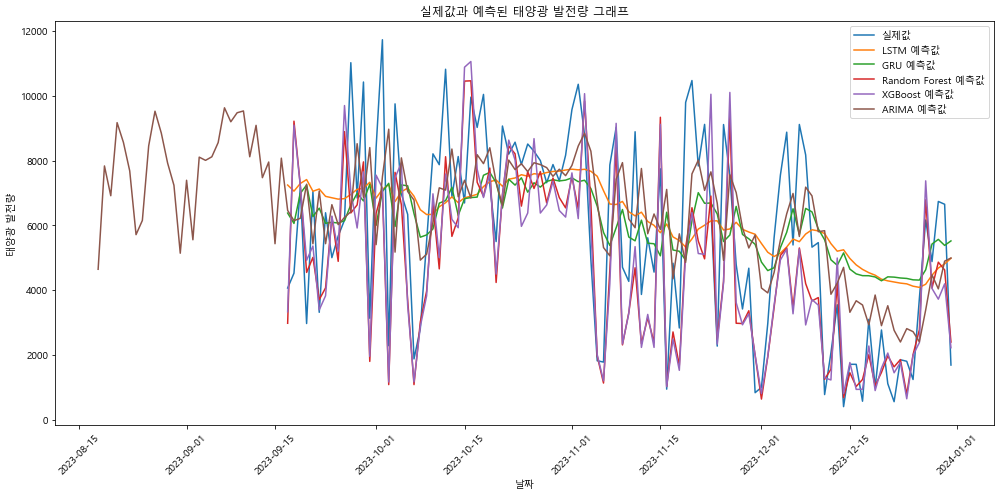

In [54]:
# 실제값과 예측값 시각화
plt.figure(figsize=(14, 7))

# 실제값 처리
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
actual_index = df.index[train_size+val_size+time_steps:train_size+val_size+time_steps+len(y_test_inv)]
plt.plot(actual_index, y_test_inv, label='실제값')

for name in model_names:
    if name in ['LSTM', 'GRU']:
        y_pred = results[name]['Best Model'].predict(X_test_seq)
        y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()
    elif name == 'ARIMA':
        y_pred_inv = y_pred_arima_df
        y_pred_inv_index = y_pred_arima_df.index
    else:
        y_pred = results[name]['Best Model'].predict(X_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    if name == 'ARIMA':
        plt.plot(y_pred_inv_index, y_pred_inv, label=f'{name} 예측값')
    else:
        pred_index = df.index[train_size+val_size+time_steps:train_size+val_size+time_steps+len(y_pred_inv)]
        plt.plot(pred_index, y_pred_inv, label=f'{name} 예측값')

plt.legend()
plt.title('실제값과 예측된 태양광 발전량 그래프')
plt.xlabel('날짜')
plt.ylabel('태양광 발전량')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# 각 모델의 RMSE 계산 및 출력
print("\n각 모델의 RMSE:")
for name in model_names:
    if name in ['LSTM', 'GRU']:
        y_pred = results[name]['Best Model'].predict(X_test_seq)
        y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()
        y_pred_inv = y_pred_inv[:len(y_test_inv)]  # 예측값 길이 조정
    elif name == 'ARIMA':
        y_pred_inv = y_pred_arima_df.values
        y_pred_inv = y_pred_inv[:len(y_test_inv)]  # 예측값 길이 조정
    else:
        y_pred = results[name]['Best Model'].predict(X_test)
        y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_pred_inv = y_pred_inv[:len(y_test_inv)]  # 예측값 길이 조정

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    print(f"{name} RMSE: {rmse:.4f}")


각 모델의 RMSE:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
LSTM RMSE: 2690.0737
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
GRU RMSE: 2609.3161
Random Forest RMSE: 2030.6082
XGBoost RMSE: 2150.0116
ARIMA RMSE: 3477.9065


In [56]:
# 모델 성능 비교 테이블 생성
performance_data = {
    'Model': model_names,
    'MSE': [results[model]['MSE'] for model in model_names],
    'MAE': [results[model]['MAE'] for model in model_names],
    'NMAE': [results[model]['NMAE'] for model in model_names],
    'R2': [results[model]['R2'] for model in model_names],
    'Accuracy': [results[model]['Accuracy'] for model in model_names]
}

performance_df = pd.DataFrame(performance_data)
print("\n모델 성능 비교 테이블:")
print(performance_df.to_string(index=False))


모델 성능 비교 테이블:
        Model          MSE         MAE      NMAE       R2  Accuracy
         LSTM 7.236497e+06 2220.925302 92.523134 0.190026 19.002631
          GRU 6.808531e+06 2160.566194 90.008590 0.237928 23.792813
Random Forest 4.123370e+06 1607.174712 66.954454 0.538475 53.847545
      XGBoost 4.622550e+06 1710.878550 71.274727 0.482603 48.260271
        ARIMA 7.157377e+06 2175.958924 90.649847 0.260654 26.065439


In [57]:
# 최고 성능 모델 선정
best_model = performance_df.loc[performance_df['R2'].idxmax()]
print(f"\n최고 성능 모델: {best_model['Model']}")
print(f"R2 점수: {best_model['R2']:.4f}")
print(f"정확도: {best_model['Accuracy']:.2f}%")
print(f"MSE: {best_model['MSE']:.4f}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"NMAE: {best_model['NMAE']:.4f}%")


최고 성능 모델: Random Forest
R2 점수: 0.5385
정확도: 53.85%
MSE: 4123369.6040
MAE: 1607.1747
NMAE: 66.9545%


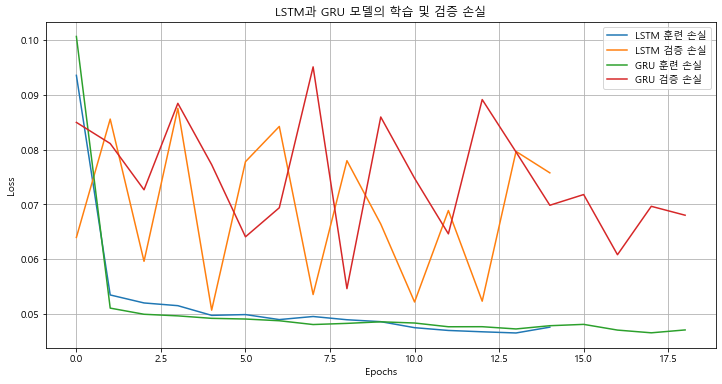

In [58]:
# 손실 그래프 시각화 (LSTM과 GRU 모델)
plt.figure(figsize=(12, 6))

if 'LSTM' in results and 'History' in results['LSTM']:
    plt.plot(results['LSTM']['History'].history['loss'], label='LSTM 훈련 손실')
    plt.plot(results['LSTM']['History'].history['val_loss'], label='LSTM 검증 손실')

if 'GRU' in results and 'History' in results['GRU']:
    plt.plot(results['GRU']['History'].history['loss'], label='GRU 훈련 손실')
    plt.plot(results['GRU']['History'].history['val_loss'], label='GRU 검증 손실')

plt.title('LSTM과 GRU 모델의 학습 및 검증 손실')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# 각 모델의 최종 손실값 출력
if 'LSTM' in results and 'History' in results['LSTM']:
    print(f"LSTM 최종 훈련 손실: {results['LSTM']['History'].history['loss'][-1]:.4f}")
    print(f"LSTM 최종 검증 손실: {results['LSTM']['History'].history['val_loss'][-1]:.4f}")

if 'GRU' in results and 'History' in results['GRU']:
    print(f"GRU 최종 훈련 손실: {results['GRU']['History'].history['loss'][-1]:.4f}")
    print(f"GRU 최종 검증 손실: {results['GRU']['History'].history['val_loss'][-1]:.4f}")

LSTM 최종 훈련 손실: 0.0476
LSTM 최종 검증 손실: 0.0758
GRU 최종 훈련 손실: 0.0471
GRU 최종 검증 손실: 0.0680


In [60]:
# 원래 데이터에 대한 전체 예측 수행
X_total_scaled = scaler_X.transform(df[['일조(hr)', '일사(MJ/m2)']])
y_total_scaled = scaler_y.transform(df['태양광전체'].values.reshape(-1, 1))

# RandomForest 모델로 전체 데이터에 대해 예측
rf_model = results['Random Forest']['Best Model']
y_pred_total_rf = rf_model.predict(X_total_scaled)
y_pred_total_rf_inv = scaler_y.inverse_transform(y_pred_total_rf.reshape(-1, 1)).flatten()

# 전체 데이터에 예측값 컬럼 추가
df['예측값'] = y_pred_total_rf_inv

# 결과를 CSV 파일로 저장
df.to_csv('predicted_rf_values_full.csv', index=True, encoding='utf-8-sig')

print("전체 데이터에 대한 예측 저장")

전체 데이터에 대한 예측 저장


In [61]:
!pip freeze
!pip freeze > requirements.txt

absl-py==2.1.0
argon2-cffi==21.1.0
asgiref==3.6.0
astunparse==1.6.3
attrs==23.2.0
backcall==0.2.0
beautifulsoup4==4.12.3
bitstring==4.0.2
bleach==4.1.0
branca==0.7.1
cachetools==5.3.3
certifi==2024.2.2
cffi==1.15.0
charset-normalizer==3.3.2
colorama==0.4.4
contourpy==1.0.7
cryptography==40.0.2
cycler==0.11.0
Cython==3.0.10
db-dtypes==1.2.0
debugpy==1.5.0
decorator==5.1.0
defusedxml==0.7.1
Django==4.1.5
ecdsa==0.18.0
entrypoints==0.3
esptool==4.5.1
et-xmlfile==1.1.0
exceptiongroup==1.2.0
flatbuffers==24.3.25
folium==0.16.0
fonttools==4.39.4
gast==0.6.0
google-api-core==2.19.0
google-auth==2.29.0
google-auth-oauthlib==1.2.0
google-cloud-bigquery==3.22.0
google-cloud-bigquery-storage==2.25.0
google-cloud-core==2.4.1
google-crc32c==1.5.0
google-pasta==0.2.0
google-resumable-media==2.7.0
googleapis-common-protos==1.63.0
grpcio==1.63.0
grpcio-status==1.62.2
h11==0.14.0
h5py==3.11.0
idna==3.6
importlib-resources==5.12.0
importlib_metadata==8.0.0
ipykernel==6.4.1
ipython==7.28.0
ipython-genuti